In [1]:
import sys
import os
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from pycgp_finalclass.Config import CGPConfig
from pycgp_finalclass.ES import ES
from pycgp_finalclass.Evaluator import EvaluatorSin, Binary_Classifier, Regressor, MultiClassClassifier,Binary_Regressor
from pycgp_finalclass.Node import Node
from pycgp_finalclass.Mutation import Golden_mutation
from pycgp_finalclass.Function import Func
from pycgp_finalclass.Function_library import *
from pycgp_finalclass.Genome import CGPGenome


In [2]:
def build_funcLib(): #Define the function used
    return [Func(f_sum, 'sum', 2, 0),
            Func(f_aminus, 'aminus', 2, 0),
            Func(f_mult, 'mult', 2, 0),
            #Func(f_exp, 'exp', 2, 0),
            Func(f_abs, 'abs', 1, 0),
            Func(f_sqrt, 'sqrt', 1, 0),
            Func(f_sqrtxy, 'sqrtxy', 2, 0),
            Func(f_squared, 'squared', 1, 0),
            Func(f_pow, 'pow', 2, 0),
            Func(f_one, 'one', 0, 0),
            Func(f_zero, 'zero', 0, 0),
            Func(f_const, 'const', 0, 1),
            Func(f_inv, 'inv', 1, 0),
            Func(f_gt, 'gt', 2, 0),
            #Func(f_asin, 'asin', 1, 0),
            #Func(f_acos, 'acos', 1, 0),
            #Func(f_atan, 'atan', 1, 0),
            #Func(f_sin, 'sin', 1, 0),
            Func(f_min, 'min', 2, 0),
            Func(f_max, 'max', 2, 0),
            Func(f_round, 'round', 1, 0),
            #Func(f_floor, 'floor', 1, 0),
            #Func(f_ceil, 'ceil', 1, 0)
            ]
functions = build_funcLib()

In [12]:




#Initialise config + Evaluator + mutation 
CGP_config = CGPConfig(num_inputs=1, num_nodes=30, num_outputs=1, input_node_chance=0.4, const_min=-1, const_max=1, function_set=functions)
#For evaluatorsin num_inputs = 1

#mutationcgp_proba = Proba_Mutation(CGP_config, number_mutations=10, input_node_mutation_rate=0.2, output_node_mutation_rate=0.1, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1)
mutationcgp_golden = Golden_mutation(CGP_config,input_node_mutation_rate=0.2, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1,output_node_mutation_rate=0.1)

evaluator1 = EvaluatorSin()

#Test purpose
genome_cgp = CGPGenome.create_genome(CGP_config)
active_nodes = genome_cgp.get_active_nodes()
print("Active nodes:", active_nodes)



Active nodes: [<pycgp_finalclass.Node.Node object at 0x0000024335D09FD0>, <pycgp_finalclass.Node.Node object at 0x0000024335D08F20>, <pycgp_finalclass.Node.Node object at 0x0000024335D0A7E0>]


Starting fitness 0.6190


Early Stop at Gen 191:   2%|▏         | 191/10000 [00:02<02:12, 74.31gen/s]



Best fitness achieved: 0.9860
n1 = sum(x0, x0)
n2 = aminus(n1, x0)
n3 = squared(n1)
n4 = aminus(n1, n1)
n5 = mult(n3, n2)
n6 = sqrtxy(x0, n4)
n7 = abs(x0)
n8 = aminus(n1, n1)
n9 = sum(n5, n6)
n10 = aminus(n5, n4)
n11 = const()
n12 = zero()
n13 = sum(n1, n12)
n14 = squared(n4)
n15 = mult(n14, n6)
n16 = aminus(n8, x0)
n17 = one()
n18 = zero()
n19 = mult(n7, n16)
n20 = sqrt(n16)
n21 = sum(n4, x0)
n22 = sqrt(x0)
n23 = zero()
n24 = abs(x0)
n25 = sqrt(x0)
n26 = one()
n27 = sum(x0, n23)
n28 = sqrt(n16)
n29 = abs(x0)
n30 = mult(n26, n24)
Outputs: n1

Unrolled output expression 0:
sum(x0, x0)



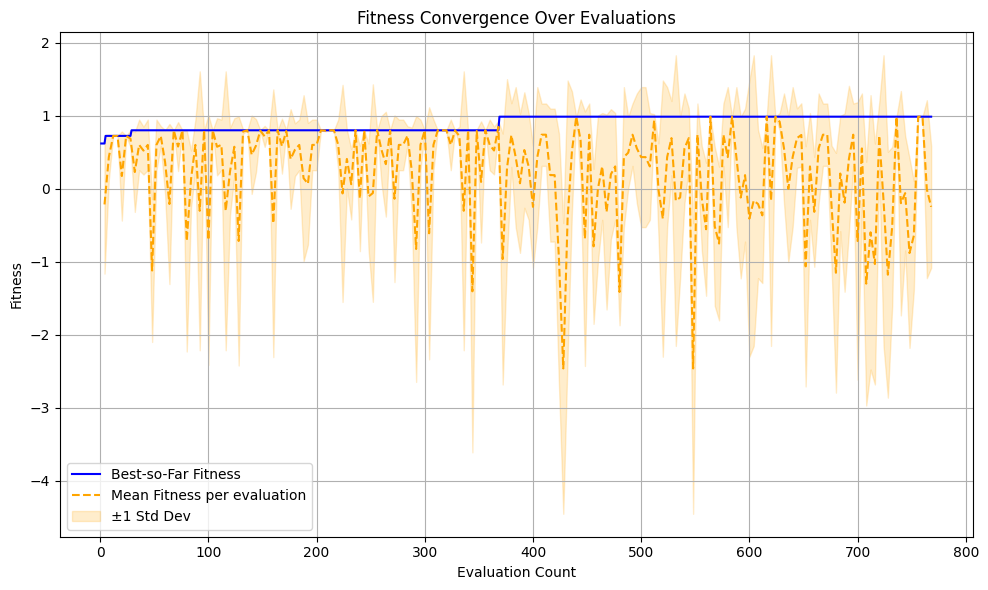

c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\pycgp_finalclass\Genome.py:243: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


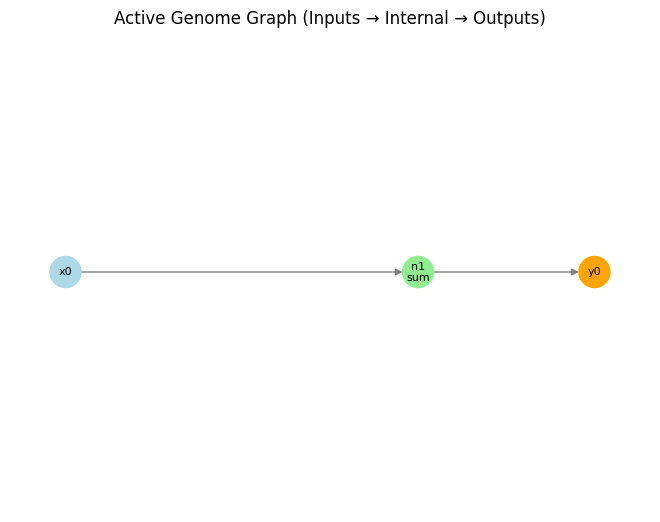

n1 = sum(x0, x0)
n2 = aminus(n1, x0)
n3 = squared(n1)
n4 = aminus(n1, n1)
n5 = mult(n3, n2)
n6 = sqrtxy(x0, n4)
n7 = abs(x0)
n8 = aminus(n1, n1)
n9 = sum(n5, n6)
n10 = aminus(n5, n4)
n11 = const()
n12 = zero()
n13 = sum(n1, n12)
n14 = squared(n4)
n15 = mult(n14, n6)
n16 = aminus(n8, x0)
n17 = one()
n18 = zero()
n19 = mult(n7, n16)
n20 = sqrt(n16)
n21 = sum(n4, x0)
n22 = sqrt(x0)
n23 = zero()
n24 = abs(x0)
n25 = sqrt(x0)
n26 = one()
n27 = sum(x0, n23)
n28 = sqrt(n16)
n29 = abs(x0)
n30 = mult(n26, n24)
Outputs: n1

Unrolled output expression 0:
sum(x0, x0)



In [13]:
#Initialise the ES and run the evolution
ES_cgp = ES(evaluator1, lam=4, parent = CGPGenome.create_genome(CGP_config),mutation = mutationcgp_golden)
best_genome = ES_cgp.evolve(n_generations=10000, early_stopping=100,verbose=True)

print(best_genome.to_function_string())


n1 = sum(x0, x0)
n2 = aminus(n1, x0)
n3 = squared(n1)
n4 = aminus(n1, n1)
n5 = mult(n3, n2)
n6 = sqrtxy(x0, n4)
n7 = abs(x0)
n8 = aminus(n1, n1)
n9 = sum(n5, n6)
n10 = aminus(n5, n4)
n11 = const()
n12 = zero()
n13 = sum(n1, n12)
n14 = squared(n4)
n15 = mult(n14, n6)
n16 = aminus(n8, x0)
n17 = one()
n18 = zero()
n19 = mult(n7, n16)
n20 = sqrt(n16)
n21 = sum(n4, x0)
n22 = sqrt(x0)
n23 = zero()
n24 = abs(x0)
n25 = sqrt(x0)
n26 = one()
n27 = sum(x0, n23)
n28 = sqrt(n16)
n29 = abs(x0)
n30 = mult(n26, n24)
Outputs: n1

Unrolled output expression 0:
sum(x0, x0)



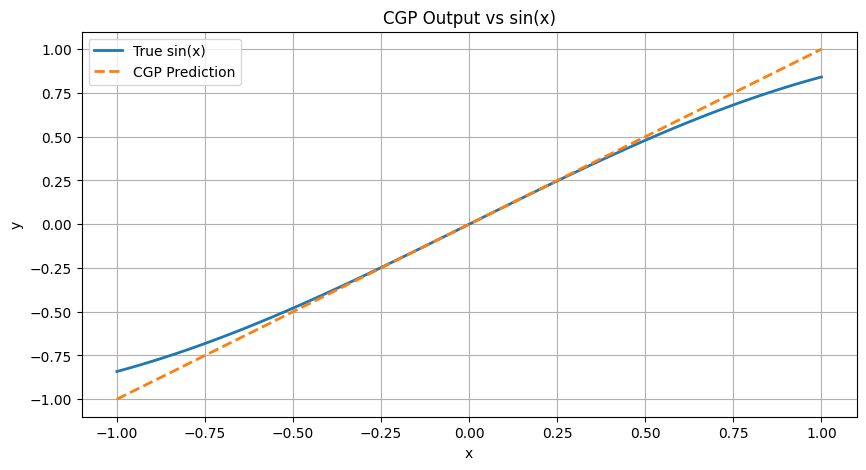

Fitness of best genome: 0.985955675414213


In [14]:
#See if the output fit the sin function

import matplotlib.pyplot as plt

def plot_sin_vs_prediction(evaluator, genome):
    inputs = evaluator.inputs
    targets = evaluator.targets

    predictions = [genome.get_value([x])[0] for x in inputs]

    plt.figure(figsize=(10, 5))
    plt.plot(inputs, targets, label='True sin(x)', linewidth=2)
    plt.plot(inputs, predictions, label='CGP Prediction', linestyle='--', linewidth=2)
    plt.title('CGP Output vs sin(x)')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()
print(best_genome.to_function_string())
plot_sin_vs_prediction(evaluator1, best_genome)
print(f"Fitness of best genome: {evaluator1.evaluate(best_genome)}")


Starting fitness -0.5385

Best fitness achieved: 0.4612
n4 = aminus(x0, x2)
n5 = sin(n4)
n6 = const()
n7 = asin(x1)
n8 = exp(n5, n5)
n9 = gt(n6, n4)
n10 = asin(n6)
n11 = abs(n9)
n12 = aminus(x2, n10)
n13 = sum(n12, n5)
n14 = min(x0, n9)
n15 = ceil(n4)
n16 = gt(n5, x3)
n17 = one()
n18 = round(x2)
n19 = exp(n16, x2)
n20 = sqrt(n16)
n21 = gt(x3, n19)
n22 = floor(x3)
n23 = sqrt(n13)
n24 = round(n14)
n25 = const()
n26 = sum(n8, n18)
n27 = exp(x2, n16)
n28 = floor(n5)
n29 = sqrtxy(n14, x2)
n30 = round(n7)
n31 = sqrt(n9)
n32 = round(n8)
n33 = aminus(x2, n17)
Outputs: n6, n24, n32, n33, n16, n8, n25, n27, n28

Unrolled output expression 0:
const()
Unrolled output expression 1:
round(min(x0, gt(const(), aminus(x0, x2))))
Unrolled output expression 2:
round(exp(sin(aminus(x0, x2)), sin(aminus(x0, x2))))
Unrolled output expression 3:
aminus(x2, one())
Unrolled output expression 4:
gt(sin(aminus(x0, x2)), x3)
Unrolled output expression 5:
exp(sin(aminus(x0, x2)), sin(aminus(x0, x2)))
Unrolled outp

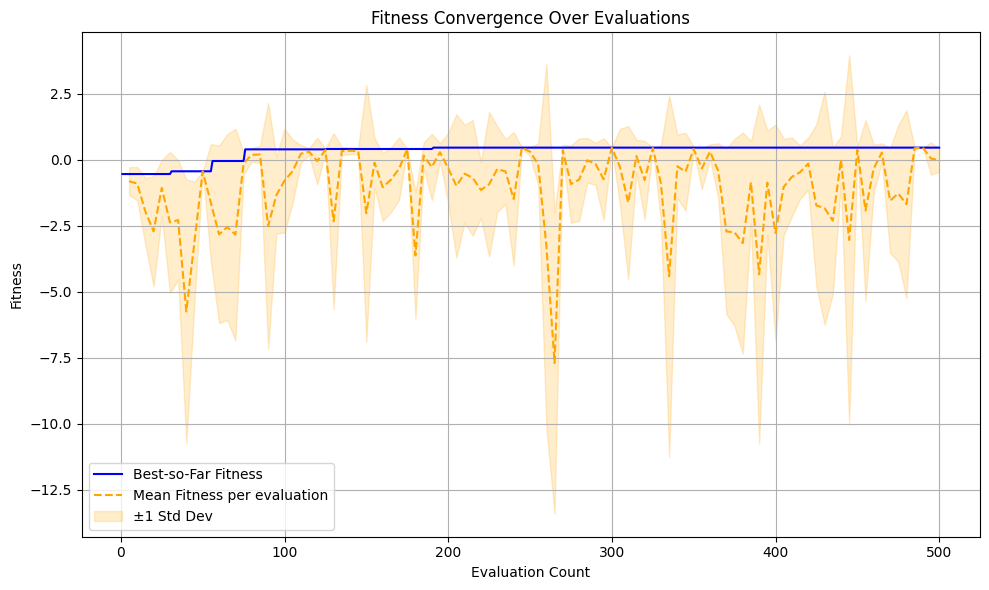

c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\pycgp_finalclass\Genome.py:243: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


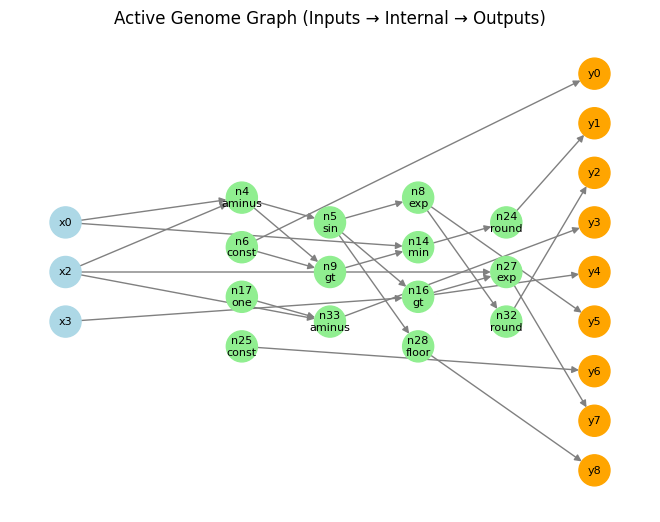

In [4]:
##WORK IN PROGRESS

from pmlb import fetch_data
from sklearn.preprocessing import MinMaxScaler

# Returns NumPy arrays
gametes = fetch_data('1027_ESL')
X, y = fetch_data('1027_ESL', return_X_y=True, local_cache_dir='./datasets')

# Conversion des colonnes en float
X = X.astype(float)
y = y.astype(float)

# Standardisation avec MinMaxScaler dans l'intervalle [-1, 1]
scaler = MinMaxScaler(feature_range=(-1, 1))
X = scaler.fit_transform(X)

evaluator2 = Regressor(X, y)

#Initialise config + Evaluator + mutation 
CGP_config = CGPConfig(num_inputs=X.shape[1], num_nodes=30, num_outputs=9, input_node_chance=0.4, const_min=-1, const_max=1, function_set=functions)
#For evaluatorsin num_inputs = 1

#mutationcgp_proba = Proba_Mutation(CGP_config, number_mutations=10, input_node_mutation_rate=0.2, output_node_mutation_rate=0.1, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1)
mutationcgp_golden = Golden_mutation(CGP_config,input_node_mutation_rate=0.2, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1,output_node_mutation_rate=0.5)
ES_cgp = ES(evaluator2, lam=5,parent = CGPGenome.create_genome(CGP_config),mutation = mutationcgp_golden)
best_genome = ES_cgp.evolve(n_generations=100, early_stopping=100, verbose=True)



In [5]:
from pmlb import fetch_data
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
import pandas as pd

# --- Load the dataset ---
X, y = fetch_data('1027_ESL', return_X_y=True, local_cache_dir='./datasets')

# --- Split the dataset ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Optional: Standardize features for models that benefit from it (SVM, KNN, Ridge, etc.) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Define regression models ---
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor': SVR(),
    'KNN Regressor': KNeighborsRegressor()
}

# --- Evaluate R² for each model ---
results = {}

for name, model in models.items():
    if name in ['Support Vector Regressor', 'KNN Regressor', 'Ridge Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    results[name] = r2
    print(f"{name}: R² score = {r2:.4f}")

# --- Show sorted results ---
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['R2 Score'])
df_results = df_results.sort_values('R2 Score', ascending=False)
print("\n=== Sorted Results ===")
print(df_results)

print("\n=== CGP result ===")
print(f"CGP: R² score = {evaluator2.evaluate(best_genome)}")


Linear Regression: R² score = 0.8234
Ridge Regression: R² score = 0.8233
Random Forest: R² score = 0.7418
Gradient Boosting: R² score = 0.8038
Support Vector Regressor: R² score = 0.8075
KNN Regressor: R² score = 0.8001

=== Sorted Results ===
                          R2 Score
Linear Regression         0.823357
Ridge Regression          0.823297
Support Vector Regressor  0.807521
Gradient Boosting         0.803834
KNN Regressor             0.800066
Random Forest             0.741804

=== CGP result ===
CGP: R² score = 0.4612174604226005


Starting fitness 0.1098


Gen 1468 | Best: 0.8497:  49%|████▉     | 2469/5000 [20:43<28:18,  1.49gen/s]

different genome


Gen 1468 | Best: 0.8497:  69%|██████▉   | 3470/5000 [26:42<07:43,  3.30gen/s]

different genome


Gen 1468 | Best: 0.8497:  89%|████████▉ | 4469/5000 [30:08<01:56,  4.56gen/s]

different genome


Gen 1468 | Best: 0.8497: 100%|██████████| 5000/5000 [32:40<00:00,  2.55gen/s]



Best fitness achieved: 0.8497
n6 = min(x5, x3)
n7 = max(n6, n6)
n8 = const()
n9 = const()
n10 = min(x4, n7)
n11 = abs(n7)
n12 = min(x3, x1)
n13 = sqrtxy(n10, n9)
n14 = sqrtxy(n13, n11)
n15 = min(n9, n6)
n16 = sqrtxy(n7, n9)
n17 = sqrtxy(x5, n6)
n18 = aminus(x3, x2)
n19 = inv(n15)
n20 = mult(x2, n12)
n21 = min(n20, n13)
n22 = mult(n7, n17)
n23 = pow(n15, n21)
n24 = min(n12, x0)
n25 = one()
n26 = mult(n19, n17)
n27 = min(n17, n23)
n28 = sqrtxy(n9, n19)
n29 = aminus(n28, n27)
n30 = inv(x1)
n31 = sqrt(n22)
n32 = zero()
n33 = pow(n32, n16)
n34 = squared(n24)
n35 = gt(n6, n24)
Outputs: n27, n35, n35, n15

Unrolled output expression 0:
min(sqrtxy(x5, min(x5, x3)), pow(min(const(), min(x5, x3)), min(mult(x2, min(x3, x1)), sqrtxy(min(x4, max(min(x5, x3), min(x5, x3))), const()))))
Unrolled output expression 1:
gt(min(x5, x3), min(min(x3, x1), x0))
Unrolled output expression 2:
gt(min(x5, x3), min(min(x3, x1), x0))
Unrolled output expression 3:
min(const(), min(x5, x3))



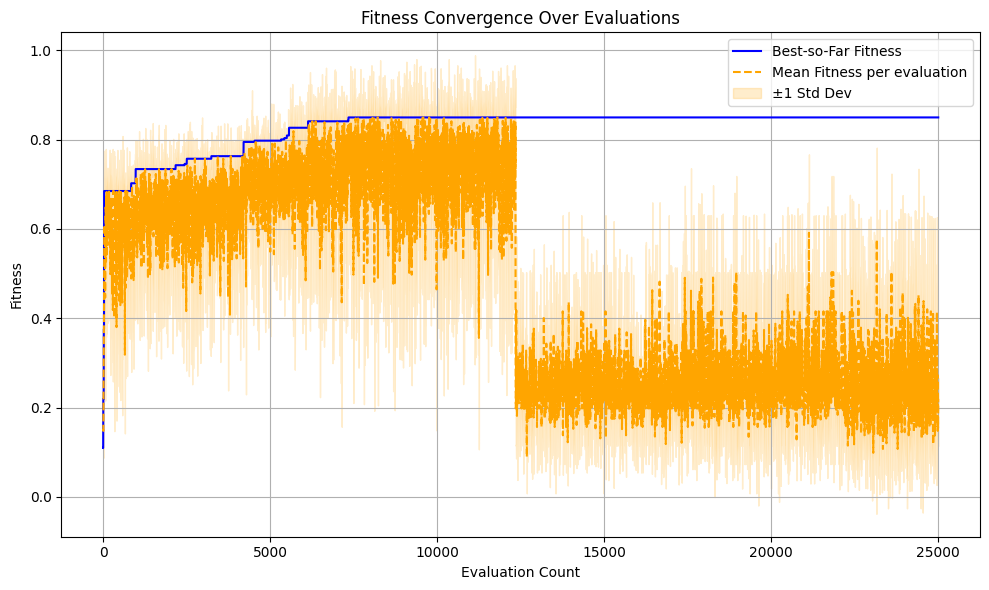

c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\pycgp_finalclass\Genome.py:243: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


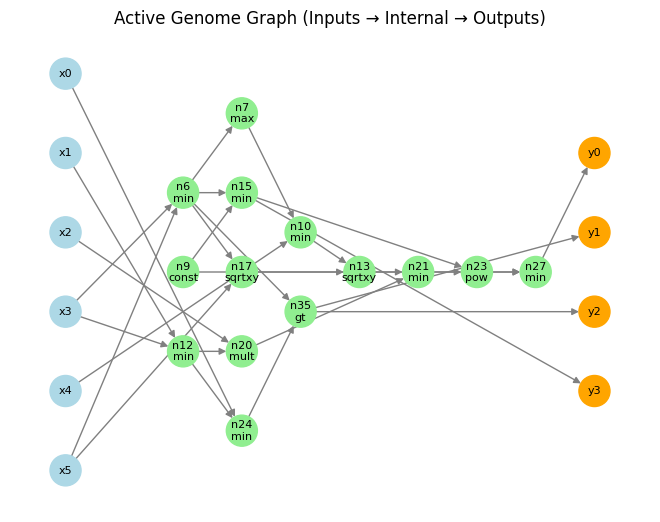

In [4]:
##WORK IN PROGRESS

from pmlb import fetch_data
from sklearn.preprocessing import MinMaxScaler

# Returns NumPy arrays
gametes = fetch_data('car_evaluation')
X, y = fetch_data('car_evaluation', return_X_y=True, local_cache_dir='./datasets')

# Conversion des colonnes en float
X = X.astype(float)
y = y.astype(float)


# Standardisation avec MinMaxScaler dans l'intervalle [-1, 1]
scaler = MinMaxScaler(feature_range=(-1, 1))
X = scaler.fit_transform(X)

evaluator2 = MultiClassClassifier(X, y)

#Initialise config + Evaluator + mutation 
CGP_config = CGPConfig(num_inputs=X.shape[1], num_nodes=30, num_outputs=4, input_node_chance=0.4, const_min=-1, const_max=1, function_set=functions)
#For evaluatorsin num_inputs = 1

#mutationcgp_proba = Proba_Mutation(CGP_config, number_mutations=10, input_node_mutation_rate=0.2, output_node_mutation_rate=0.1, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1)
mutationcgp_golden = Golden_mutation(CGP_config,input_node_mutation_rate=0.2, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1,output_node_mutation_rate=0.5)
ES_cgp = ES(evaluator2, lam=5,parent_factory=lambda: CGPGenome.create_genome(CGP_config),mutation = mutationcgp_golden)
best_genome = ES_cgp.evolve(n_generations=5000, early_stopping=5000,early_switch=1000, verbose=True)



In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# --- Load the dataset ---
X, y = fetch_data('car_evaluation', return_X_y=True, local_cache_dir='./datasets')

# --- Split the dataset ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Optional: Standardize features for models that benefit from it (SVM, KNN, Ridge, etc.) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Define classification models ---
models = {
    'Logistic Regression': LogisticRegression(max_iter=100000),
    'Ridge Classifier': RidgeClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Support Vector Classifier': SVC(),
    'KNN Classifier': KNeighborsClassifier()
}

# --- Evaluate accuracy for each model ---
results = {}

for name, model in models.items():
    if name in ['Support Vector Classifier', 'KNN Classifier', 'Ridge Classifier']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: Accuracy = {acc:.4f}")

# --- Show sorted results ---
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
df_results = df_results.sort_values('Accuracy', ascending=False)
print("\n=== Sorted Results ===")
print(df_results)


print("\n=== CGP result ===")
print(f"CGP: accuracy score = {evaluator2.evaluate(best_genome)}")


Logistic Regression: Accuracy = 0.8121
Ridge Classifier: Accuracy = 0.7341
Random Forest: Accuracy = 0.9624
Gradient Boosting: Accuracy = 0.9682
Support Vector Classifier: Accuracy = 0.9624
KNN Classifier: Accuracy = 0.9480

=== Sorted Results ===
                           Accuracy
Gradient Boosting          0.968208
Random Forest              0.962428
Support Vector Classifier  0.962428
KNN Classifier             0.947977
Logistic Regression        0.812139
Ridge Classifier           0.734104

=== CGP result ===
CGP: accuracy score = 0.8497109826589595


Starting fitness 0.1588
Generation 0
Generation 1

Best fitness this generation: 0.2059
n6 = floor(x1)
n7 = zero()
n8 = const()
n9 = exp(x0, x2)
n10 = one()
n11 = acos(n10)
n12 = zero()
n13 = atan(n12)
n14 = sqrt(n12)
n15 = const()
n16 = round(x0)
n17 = mult(n9, x0)
n18 = sum(n11, n13)
n19 = max(x5, n8)
n20 = aminus(n11, x3)
n21 = mult(n13, n8)
n22 = asin(x4)
n23 = sqrt(n11)
n24 = sum(x3, n9)
n25 = ceil(x4)
n26 = min(x5, n22)
n27 = asin(n8)
n28 = sqrt(x5)
n29 = one()
n30 = sum(x0, n16)
n31 = inv(n19)
n32 = sqrtxy(x5, n9)
n33 = mult(n9, n6)
n34 = asin(n15)
n35 = squared(n21)
Outputs: n17, n34, n14, n13

Unrolled output expression 0:
mult(exp(x0, x2), x0)
Unrolled output expression 1:
asin(const())
Unrolled output expression 2:
sqrt(zero())
Unrolled output expression 3:
atan(zero())

Generation 2

Best fitness this generation: 0.3235
n6 = floor(x1)
n7 = zero()
n8 = const()
n9 = exp(x0, x2)
n10 = one()
n11 = acos(n10)
n12 = zero()
n13 = atan(n12)
n14 = sqrt(n12)
n15 = const()
n16 = round(

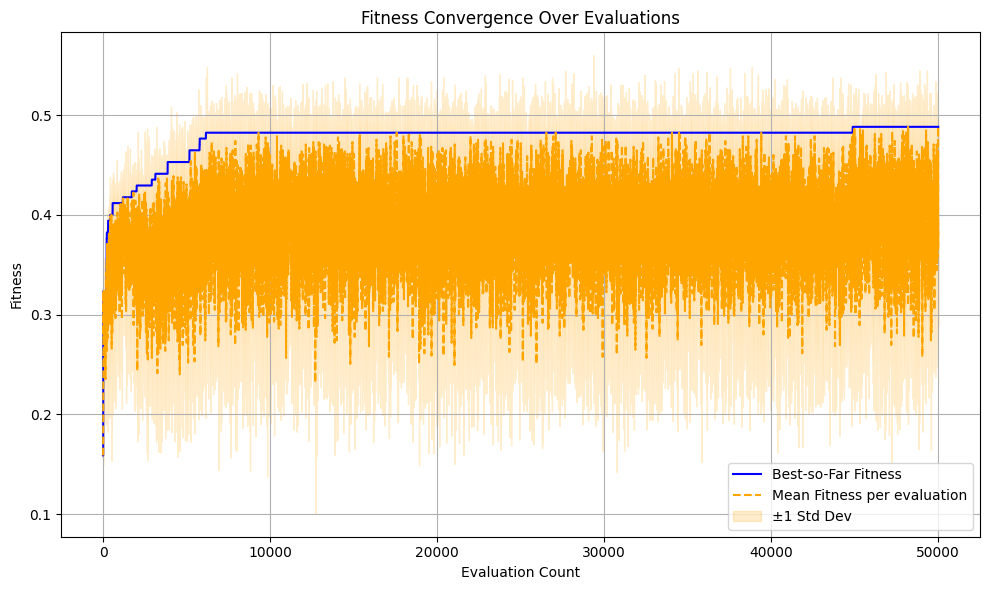

c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\pycgp_finalclass\Genome.py:243: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


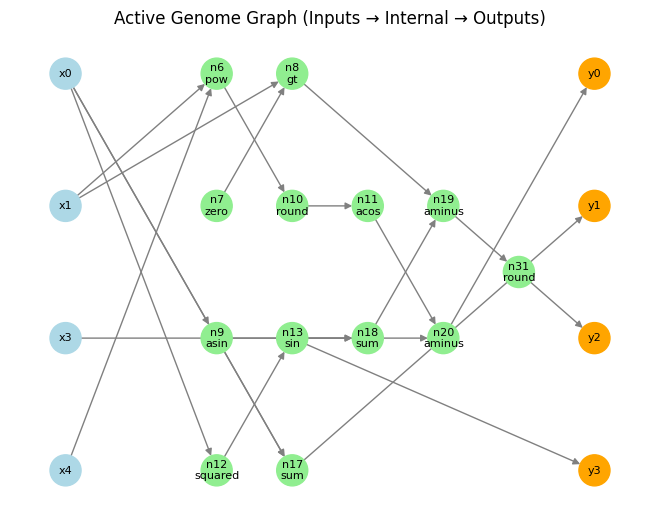

In [10]:

import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Charger le fichier CSV avec le bon séparateur
file_path = 'datasets/Audio.xlsx'
df = pd.read_excel(file_path)

# Exemple : transformer les catégories d'âge en classes numériques
age_class_mapping = {
    '[18-25[': 0,
    '[25-35[': 1,
    '[35-45[': 2,
    '[45-55]': 3
}

# Appliquer la transformation
df['age_class_num'] = df['age_class'].map(age_class_mapping)

y = df['age_class_num']

# Supprimer les lignes NaN
mask = ~y.isna()
X = df.loc[mask, 'ampl':'plat_amp'].astype(float)
y = y[mask].astype(int)  # on garde int pour les classes

scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(X)



evaluator2 = MultiClassClassifier(X_scaled, y)

#Initialise config + Evaluator + mutation 
CGP_config = CGPConfig(num_inputs=X.shape[1], num_nodes=30, num_outputs=4, input_node_chance=0.4, const_min=-1, const_max=1, function_set=functions)
#For evaluatorsin num_inputs = 1

#mutationcgp_proba = Proba_Mutation(CGP_config, number_mutations=10, input_node_mutation_rate=0.2, output_node_mutation_rate=0.1, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1)
mutationcgp_golden = Golden_mutation(CGP_config,input_node_mutation_rate=0.2, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1,output_node_mutation_rate=0.5)
ES_cgp = ES(evaluator2, lam=5,parent = CGPGenome.create_genome(CGP_config),mutation = mutationcgp_golden)
best_genome = ES_cgp.evolve(n_generations=10000, early_stopping=10000, verbose=True)


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Charger le fichier CSV avec le bon séparateur
file_path = 'datasets/Audio.xlsx'
df = pd.read_excel(file_path)

# Exemple : transformer les catégories d'âge en classes numériques
age_class_mapping = {
    '[18-25[': 0,
    '[25-35[': 1,
    '[35-45[': 2,
    '[45-55]': 3
}

# Appliquer la transformation
df['age_class_num'] = df['age_class'].map(age_class_mapping)

y = df['age_class_num']

# Supprimer les lignes NaN
mask = ~y.isna()
X = df.loc[mask, 'ampl':'plat_amp'].astype(float)
y = y[mask].astype(int)  # on garde int pour les classes


# --- Split the dataset ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Optional: Standardize features for models that benefit from it (SVM, KNN, Ridge, etc.) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --- Define classification models ---
models = {
    'Logistic Regression': LogisticRegression(max_iter=100000),
    'Ridge Classifier': RidgeClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Support Vector Classifier': SVC(),
    'KNN Classifier': KNeighborsClassifier()
}

# --- Evaluate accuracy for each model ---
results = {}

for name, model in models.items():
    if name in ['Support Vector Classifier', 'KNN Classifier', 'Ridge Classifier']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: Accuracy = {acc:.4f}")

# --- Show sorted results ---
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
df_results = df_results.sort_values('Accuracy', ascending=False)
print("\n=== Sorted Results ===")
print(df_results)


print("\n=== CGP result ===")
print(f"CGP: accuracy score = {evaluator2.evaluate(best_genome)}")


c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: Accuracy = 0.3471
Ridge Classifier: Accuracy = 0.3529
Random Forest: Accuracy = 0.3059
Gradient Boosting: Accuracy = 0.3294
Support Vector Classifier: Accuracy = 0.3412
KNN Classifier: Accuracy = 0.3000

=== Sorted Results ===
                           Accuracy
Ridge Classifier           0.352941
Logistic Regression        0.347059
Support Vector Classifier  0.341176
Gradient Boosting          0.329412
Random Forest              0.305882
KNN Classifier             0.300000

=== CGP result ===
CGP: accuracy score = 0.5591603053435115


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Charger le fichier CSV avec le bon séparateur
file_path = 'datasets/synth_table_anthr.csv'
df = pd.read_csv(file_path, sep=';')

# Exemple : transformer les catégories d'âge en classes numériques
sex_mapping = {
    'F': 0,
    'M': 1,
}

# Appliquer la transformation
df['sex_num'] = df['sex'].map(sex_mapping)

# Cible
y = df['sex_num']

# Sélection des colonnes freq0 à freq256
X = df.loc[:, 'f_max':'plat_amp'].astype(float)


# --- Split the dataset ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Optional: Standardize features for models that benefit from it (SVM, KNN, Ridge, etc.) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --- Define classification models ---
models = {
    'Logistic Regression': LogisticRegression(max_iter=100000),
    'Ridge Classifier': RidgeClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Support Vector Classifier': SVC(),
    'KNN Classifier': KNeighborsClassifier()
}

# --- Evaluate accuracy for each model ---
results = {}

for name, model in models.items():
    if name in ['Support Vector Classifier', 'KNN Classifier', 'Ridge Classifier']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: Accuracy = {acc:.4f}")

# --- Show sorted results ---
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
df_results = df_results.sort_values('Accuracy', ascending=False)
print("\n=== Sorted Results ===")
print(df_results)


print("\n=== CGP result ===")
print(f"CGP: accuracy score = {evaluator2.evaluate(best_genome)}")


Logistic Regression: Accuracy = 0.6088
Ridge Classifier: Accuracy = 0.6107
Random Forest: Accuracy = 0.7691
Gradient Boosting: Accuracy = 0.6355
Support Vector Classifier: Accuracy = 0.5992
KNN Classifier: Accuracy = 0.6450

=== Sorted Results ===
                           Accuracy
Random Forest              0.769084
KNN Classifier             0.645038
Gradient Boosting          0.635496
Ridge Classifier           0.610687
Logistic Regression        0.608779
Support Vector Classifier  0.599237

=== CGP result ===
CGP: accuracy score = 0.5792899475853879


Starting fitness 0.4661


Gen 851 | Best: 0.5793: 100%|██████████| 1000/1000 [02:15<00:00,  7.38gen/s]



Best fitness achieved: 0.5793
n10 = sqrtxy(x8, x2)
n11 = mult(x6, x6)
n12 = aminus(n11, n10)
n13 = gt(x5, x2)
n14 = pow(n10, x8)
n15 = min(n14, x0)
n16 = sqrtxy(n10, n13)
n17 = min(x0, n12)
n18 = max(x9, n11)
n19 = gt(n18, x0)
n20 = sqrtxy(x1, n13)
n21 = pow(n14, n16)
n22 = round(x7)
n23 = squared(n22)
n24 = sqrt(n10)
n25 = sqrt(n18)
n26 = round(n17)
n27 = abs(n23)
n28 = inv(n22)
n29 = squared(n17)
n30 = aminus(n11, n18)
n31 = mult(x8, n11)
n32 = sqrt(x8)
n33 = pow(n18, n15)
n34 = one()
n35 = abs(n18)
n36 = aminus(x2, n11)
n37 = squared(n27)
n38 = exp(n36, n36)
n39 = sqrt(n30)
Outputs: n16

Unrolled output expression 0:
sqrtxy(sqrtxy(x8, x2), gt(x5, x2))



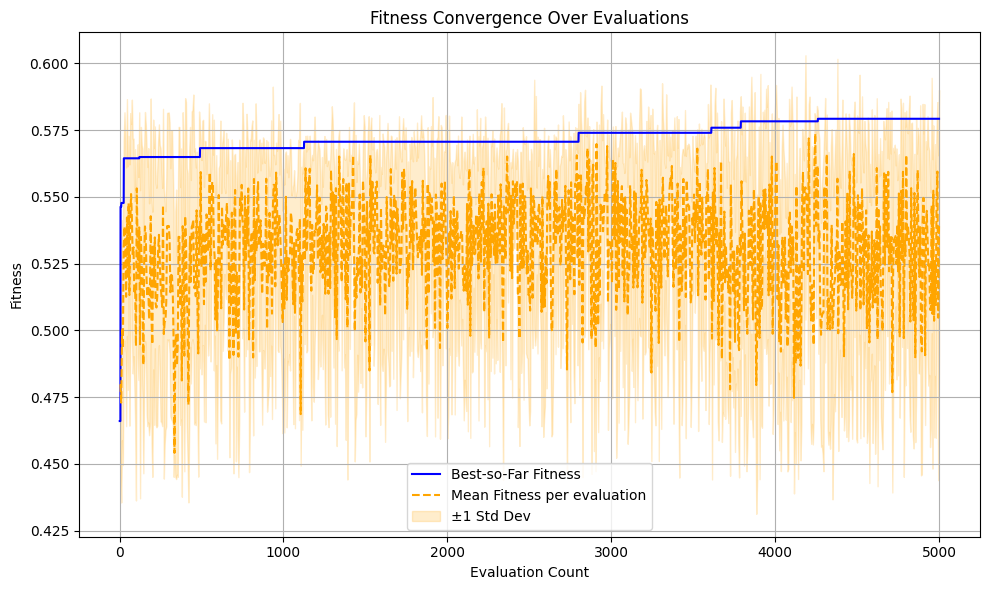

c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\pycgp_finalclass\Genome.py:243: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


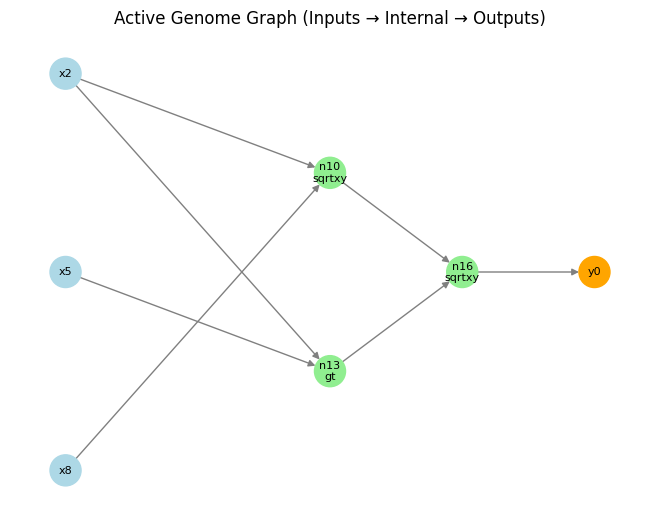

In [19]:

import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Charger le fichier CSV avec le bon séparateur
file_path = 'datasets/synth_table_anthr.csv'
df = pd.read_csv(file_path, sep=';')

# Exemple : transformer les catégories d'âge en classes numériques
sex_mapping = {
    'F': 0,
    'M': 1,
}

# Appliquer la transformation
df['sex_num'] = df['sex'].map(sex_mapping)

# Cible
y = df['sex_num']

# Sélection des colonnes freq0 à freq256
X = df.loc[:, 'f_max':'plat_amp'].astype(float)


scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(X)



evaluator2 = Binary_Classifier(X_scaled, y,cv=True)

#Initialise config + Evaluator + mutation 
CGP_config = CGPConfig(num_inputs=X.shape[1], num_nodes=30, num_outputs=1, input_node_chance=0.4, const_min=-1, const_max=1, function_set=functions)
#For evaluatorsin num_inputs = 1

#mutationcgp_proba = Proba_Mutation(CGP_config, number_mutations=10, input_node_mutation_rate=0.2, output_node_mutation_rate=0.1, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1)
mutationcgp_golden = Golden_mutation(CGP_config,input_node_mutation_rate=0.2, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1,output_node_mutation_rate=0.5)
ES_cgp = ES(evaluator2, lam=5,parent = CGPGenome.create_genome(CGP_config),mutation = mutationcgp_golden)
best_genome = ES_cgp.evolve(n_generations=1000, early_stopping=1000, verbose=True)


In [9]:

import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Charger le fichier CSV avec le bon séparateur
file_path = 'datasets/synth_table_anthr.csv'
df = pd.read_csv(file_path, sep=';')


# Cible
y = df['age']

# Sélection des colonnes freq0 à freq256
X = df.loc[:, 'ampl':'mean_5000'].astype(float)
data = pd.concat([X, y], axis=1)
data_clean = data.dropna()
X = data_clean.drop(columns=['age'])
y = data_clean['age']


scaler = MinMaxScaler(feature_range=(0,1))
X_scaled = scaler.fit_transform(X)

y = data_clean['age'].values.reshape(-1, 1)  # Reshape needed for scaler
y_scaler = MinMaxScaler(feature_range=(0, 1))
y_scaled = y_scaler.fit_transform(y)
evaluator2 = Binary_Regressor(X_scaled, y_scaled, cv=False)

#Initialise config + Evaluator + mutation 
CGP_config = CGPConfig(num_inputs=X.shape[1], num_nodes=30, num_outputs=1, input_node_chance=0.4, const_min=-1, const_max=1, function_set=functions)
#For evaluatorsin num_inputs = 1

#mutationcgp_proba = Proba_Mutation(CGP_config, number_mutations=10, input_node_mutation_rate=0.2, output_node_mutation_rate=0.1, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1)
mutationcgp_golden = Golden_mutation(CGP_config,input_node_mutation_rate=0.2, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1,output_node_mutation_rate=0.5)
ES_cgp = ES(evaluator2, lam=5,parent = CGPGenome.create_genome(CGP_config),mutation = mutationcgp_golden)
best_genome = ES_cgp.evolve(n_generations=10000, early_stopping=10000, verbose=True, project_name= "age_classif")


Starting fitness -0.8473


Gen 2474 | Best: -0.0000:  34%|███▍      | 3432/10000 [08:22<16:02,  6.83gen/s]


KeyboardInterrupt: 

In [4]:
from pmlb import fetch_data
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
import pandas as pd



# --- Split the dataset ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Optional: Standardize features for models that benefit from it (SVM, KNN, Ridge, etc.) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Define regression models ---
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor': SVR(),
    'KNN Regressor': KNeighborsRegressor()
}

# --- Evaluate R² for each model ---
results = {}

for name, model in models.items():
    if name in ['Support Vector Regressor', 'KNN Regressor', 'Ridge Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    results[name] = r2
    print(f"{name}: R² score = {r2:.4f}")

# --- Show sorted results ---
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['R2 Score'])
df_results = df_results.sort_values('R2 Score', ascending=False)
print("\n=== Sorted Results ===")
print(df_results)

print("\n=== CGP result ===")
print(f"CGP: R² score = {evaluator2.evaluate(best_genome)}")


Linear Regression: R² score = 0.0559
Ridge Regression: R² score = 0.0560
Random Forest: R² score = 0.3270
Gradient Boosting: R² score = 0.1564
Support Vector Regressor: R² score = 0.0902
KNN Regressor: R² score = 0.2675

=== Sorted Results ===
                          R2 Score
Random Forest             0.327017
KNN Regressor             0.267512
Gradient Boosting         0.156389
Support Vector Regressor  0.090206
Ridge Regression          0.056022
Linear Regression         0.055936

=== CGP result ===
CGP: R² score = 0.004850323025490155


In [ ]:
# add mean to the graph and standard deviation ##DONE
# rescale to fit range of the age (to see cause 18-55 seems to not give good results)
# Changing the library of function to fit the problem (removed some functions that were not suited to age regression)
#compare to other methods (perform not so bad compare to other methods, particularly for sex classification)
#Try to break the unit test
#Test with raw data and refined data on multiple instances and compare the results
#Add save for results (txt or csv) #DONE
#Try to restart the evolution process after a certain number of generations from scratch #Normally done, still need some tests 
# try refine of inputs and functions during the evolution process (even others parameters)
#Try to see the distribution of features over time 
# Corellation between features
